# 04 — Backtest Performance: Equity Curve, Metrics & Robustness

**Series:** Piccolo ML Options Strategy Research  
**Depends on:** `03_model_training_walkforward.ipynb`


## 1. Overview

This notebook covers:

1. Applying `add_signal_columns()` to generate trading signals
2. Strategy equity curve vs SPY buy-and-hold
3. Performance metrics: Sharpe ratio, max drawdown, win rate, profit factor
4. Monthly and yearly return heatmap
5. Regime filter impact analysis (SMA-200, vol regime)
6. Robustness checks: sensitivity to thresholds, different time periods
7. Limitations and next steps


## 2. Environment Setup


In [1]:
%matplotlib inline
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import src.piccolo.config_strategy as cfg
from src.piccolo.ml_signal_engine import (
    load_feature_table_spy,
    build_path_labels,
    build_ml_table,
    train_walkforward,
    add_signal_columns,
)

print("Imports OK")


Imports OK


## 3. Generate Trading Signals


In [2]:
# ── Full pipeline: load → labels → ML table → walk-forward → signals ─────────
feat_df = load_feature_table_spy()
feat_df = build_path_labels(feat_df)
ml_df, feature_cols = build_ml_table(feat_df)

# train_walkforward returns (results_df, fold_models, fold_scalers)
results_df, fold_models, fold_scalers = train_walkforward(ml_df, feature_cols)

# add_signal_columns adds: signal_dir, position_dir
# signal_dir  = ensemble direction after confidence gates + regime filters
# position_dir = signal_dir shifted by 1 day (trade next day)
results_df = add_signal_columns(results_df)

print(f"Results shape: {results_df.shape}")
print(f"Date range:    {results_df['quote_date'].min().date()} → {results_df['quote_date'].max().date()}")

signal_counts = results_df["signal_dir"].value_counts().sort_index()
print("\nSignal distribution:")
for sig, cnt in signal_counts.items():
    direction = {-1: "Down (Short)", 0: "Flat (No trade)", 1: "Up (Long)"}.get(sig, str(sig))
    print(f"  {direction}: {cnt:,} days ({cnt/len(results_df)*100:.1f}%)")


Total months in data: 168
Using N_TRAIN_MONTHS = 36 N_TEST_MONTHS = 3
Total folds trained: 44
Total rows in results_df (before concat): 2642
Results shape: (2642, 36)
Date range:    2015-02-02 → 2026-02-19

Signal distribution:
  Down (Short): 545 days (20.6%)
  Flat (No trade): 1,099 days (41.6%)
  Up (Long): 998 days (37.8%)


## 4. Equity Curve Construction

The backtest simulates a strategy where:
- `position_dir = +1` → long SPY (earn next day's return)
- `position_dir = -1` → short SPY (earn negative of next day's return)
- `position_dir = 0`  → flat / cash (earn nothing)

`position_dir` is the 1-day-lagged `signal_dir` — signal forms at EOD, position
enters next day.  The P&L for each day is `position_dir × fwd_ret_1d`.


In [3]:
# ── Performance helper functions ──────────────────────────────────────────────
def sharpe_ratio(returns: pd.Series, periods_per_year: int = 252) -> float:
    if returns.std() == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)

def max_drawdown(equity: pd.Series) -> float:
    roll_max = equity.cummax()
    drawdown = (equity - roll_max) / roll_max
    return drawdown.min()

def win_rate(returns: pd.Series) -> float:
    active = returns[returns != 0]
    return (active > 0).mean() if len(active) > 0 else np.nan

def profit_factor(returns: pd.Series) -> float:
    gross_profit = returns[returns > 0].sum()
    gross_loss   = abs(returns[returns < 0].sum())
    return gross_profit / gross_loss if gross_loss > 0 else np.nan

print("Performance helper functions defined.")


Performance helper functions defined.


In [4]:
# ── Build daily P&L series ────────────────────────────────────────────────────
df_bt = results_df.copy().sort_values("quote_date").reset_index(drop=True)

# fwd_ret_1d is already computed by build_path_labels()
# Strategy return = position_dir × fwd_ret_1d
df_bt["strat_ret"] = df_bt["position_dir"] * df_bt["fwd_ret_1d"]
df_bt = df_bt.dropna(subset=["strat_ret", "fwd_ret_1d"])

# Equity curves
df_bt["strat_equity"] = (1 + df_bt["strat_ret"]).cumprod()
df_bt["spy_equity"]   = (1 + df_bt["fwd_ret_1d"]).cumprod()

print(f"Backtest period: {df_bt['quote_date'].min().date()} → {df_bt['quote_date'].max().date()}")
print(f"Total trading days: {len(df_bt):,}")


Backtest period: 2015-02-02 → 2026-02-19
Total trading days: 2,642


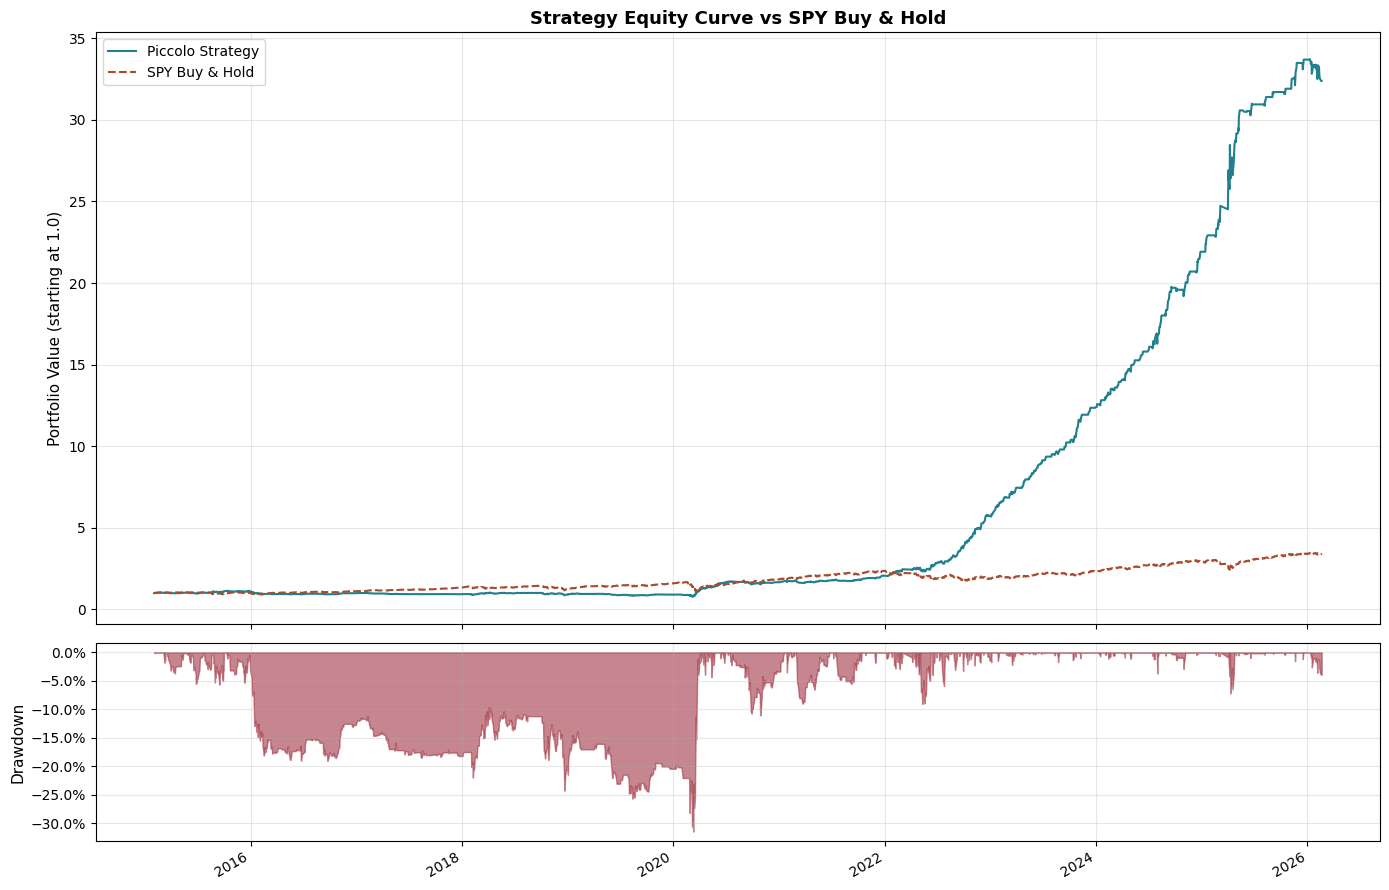

In [5]:
# ── Plot equity curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

ax1, ax2 = axes

ax1.plot(df_bt["quote_date"], df_bt["strat_equity"], color="#20808D", linewidth=1.5,
         label="Piccolo Strategy")
ax1.plot(df_bt["quote_date"], df_bt["spy_equity"],   color="#A84B2F", linewidth=1.5,
         linestyle="--", label="SPY Buy & Hold")
ax1.set_ylabel("Portfolio Value (starting at 1.0)", fontsize=11)
ax1.set_title("Strategy Equity Curve vs SPY Buy & Hold", fontsize=13, fontweight="bold")
ax1.legend()
ax1.grid(alpha=0.3)

# Drawdown
roll_max = df_bt["strat_equity"].cummax()
drawdown = (df_bt["strat_equity"] - roll_max) / roll_max
ax2.fill_between(df_bt["quote_date"], drawdown, 0, color="#A13544", alpha=0.6, label="Drawdown")
ax2.set_ylabel("Drawdown", fontsize=11)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Performance Metrics Summary


In [8]:
# ── Compute metrics ───────────────────────────────────────────────────────────
metrics = {
    "Strategy": {
        "Total Return":   df_bt["strat_equity"].iloc[-1] - 1,
        "Annualised Ret": (df_bt["strat_equity"].iloc[-1] ** (252 / len(df_bt))) - 1,
        "Sharpe Ratio":   sharpe_ratio(df_bt["strat_ret"]),
        "Max Drawdown":   max_drawdown(df_bt["strat_equity"]),
        "Win Rate":       win_rate(df_bt["strat_ret"]),
        "Profit Factor":  profit_factor(df_bt["strat_ret"]),
        "Days in Market": (df_bt["position_dir"] != 0).mean(),
    },
    "SPY B&H": {
        "Total Return":   df_bt["spy_equity"].iloc[-1] - 1,
        "Annualised Ret": (df_bt["spy_equity"].iloc[-1] ** (252 / len(df_bt))) - 1,
        "Sharpe Ratio":   sharpe_ratio(df_bt["fwd_ret_1d"]),
        "Max Drawdown":   max_drawdown(df_bt["spy_equity"]),
        "Win Rate":       win_rate(df_bt["fwd_ret_1d"]),
        "Profit Factor":  profit_factor(df_bt["fwd_ret_1d"]),
        "Days in Market": 1.0,
    }
}

metrics_df = pd.DataFrame(metrics)

# Format for display without modifying dtype
fmt = {
    "Total Return": "{:.1%}", "Annualised Ret": "{:.1%}",
    "Sharpe Ratio": "{:.3f}", "Max Drawdown": "{:.1%}",
    "Win Rate": "{:.1%}", "Profit Factor": "{:.3f}", "Days in Market": "{:.1%}",
}

display_df = metrics_df.copy().astype(object)
for row, f in fmt.items():
    display_df.loc[row] = display_df.loc[row].apply(lambda x: f.format(x))

print(display_df.to_string())

               Strategy SPY B&H
Total Return    3138.6%  241.4%
Annualised Ret    39.3%   12.4%
Sharpe Ratio      2.172   0.762
Max Drawdown     -31.5%  -34.7%
Win Rate          57.6%   55.4%
Profit Factor     1.707   1.157
Days in Market    58.4%  100.0%


## 6. Monthly Return Heatmap


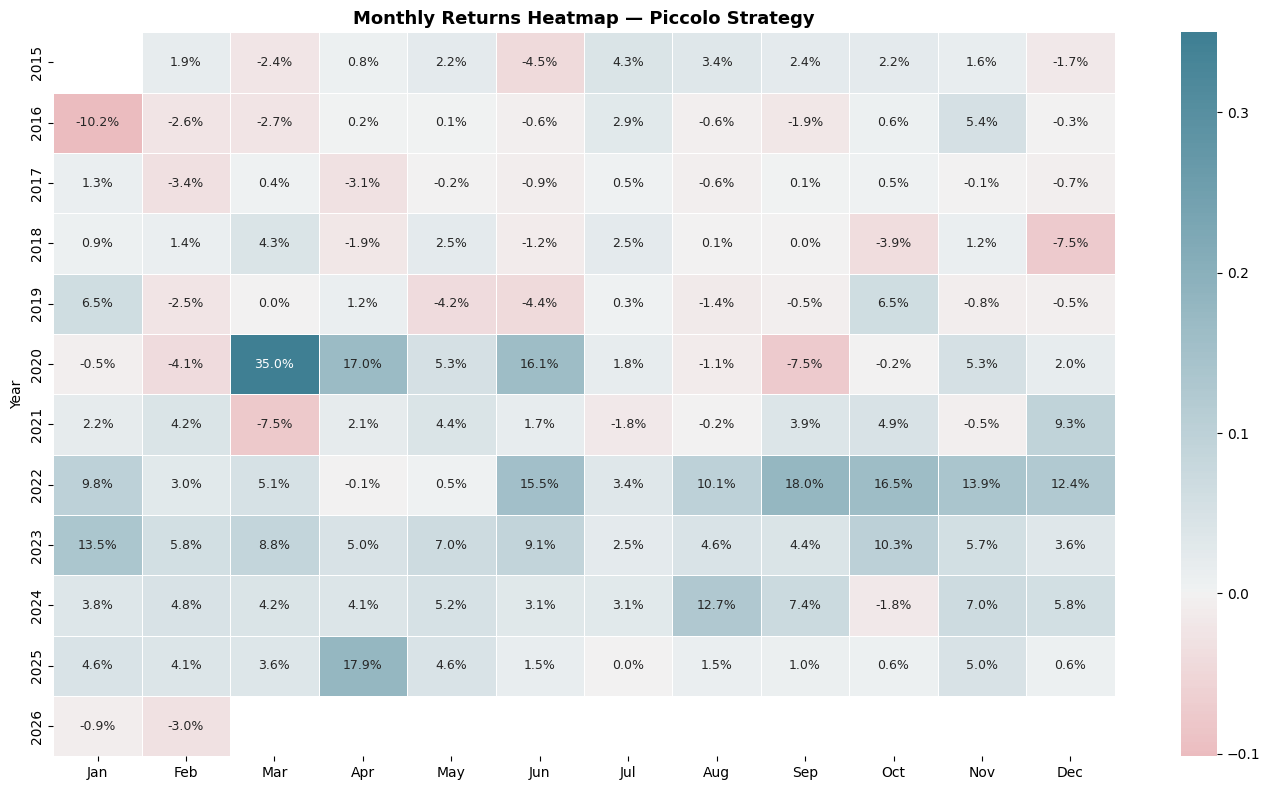

In [9]:
# ── Monthly return heatmap ────────────────────────────────────────────────────
df_bt_indexed = df_bt.set_index("quote_date")
monthly = df_bt_indexed["strat_ret"].resample("ME").apply(lambda r: (1 + r).prod() - 1)
monthly_df = monthly.to_frame("ret")
monthly_df["year"]  = monthly_df.index.year
monthly_df["month"] = monthly_df.index.month

pivot = monthly_df.pivot(index="year", columns="month", values="ret")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.5 + 2)))
sns.heatmap(
    pivot, annot=True, fmt=".1%", center=0,
    cmap=sns.diverging_palette(10, 220, as_cmap=True),
    linewidths=0.5, ax=ax, annot_kws={"size": 9}
)
ax.set_title("Monthly Returns Heatmap — Piccolo Strategy", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig("monthly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Regime Filter Impact Analysis

The strategy gates signals through regime filters configured in `config_strategy.py`:
- **SMA-200 filter** (`USE_ABOVE_SMA200_FILTER`): Suppress long signals when price < 200-day MA
- **Vol regime filter** (`USE_VOL_REGIME_FILTER`): Suppress signals when `vol_regime == 0`
- **Flat class filter** (`USE_FLAT_CLASS_FILTER`): No trade when Flat has highest ensemble prob

To measure each filter's impact, toggle them in `src/piccolo/config_strategy.py`
and re-run `add_signal_columns()`.  Below is a template for recording the comparison.


In [12]:
# ── Regime filter decomposition ───────────────────────────────────────────────
# Compare full strategy (all filters) vs raw ensemble (no filters)
df_raw = results_df.copy().sort_values("quote_date").reset_index(drop=True)
df_raw["raw_ret"] = df_raw["pred_dir_ens"].shift(1) * df_raw["fwd_ret_1d"]
df_raw = df_raw.dropna(subset=["raw_ret"])
df_raw["raw_equity"] = (1 + df_raw["raw_ret"]).cumprod()

raw_ann = (df_raw["raw_equity"].iloc[-1] ** (252 / len(df_raw))) - 1
raw_sh = sharpe_ratio(df_raw["raw_ret"])
raw_dd = max_drawdown(df_raw["raw_equity"])
raw_dim = (df_raw["pred_dir_ens"].shift(1) != 0).mean()

filt_ann = (df_bt["strat_equity"].iloc[-1] ** (252 / len(df_bt))) - 1
filt_sh = sharpe_ratio(df_bt["strat_ret"])
filt_dd = max_drawdown(df_bt["strat_equity"])
filt_dim = (df_bt["position_dir"] != 0).mean()

print("Regime Filter Impact Analysis")
print("=" * 65)
print(f"{'Scenario':<30} {'Ann. Ret':>10} {'Sharpe':>8} {'Max DD':>8} {'Days in Mkt':>12}")
print("-" * 65)
print(f"{'Full Strategy (all filters)':<30} {filt_ann:>10.1%} {filt_sh:>8.3f} {filt_dd:>8.1%} {filt_dim:>12.1%}")
print(f"{'Raw Ensemble (no filters)':<30} {raw_ann:>10.1%} {raw_sh:>8.3f} {raw_dd:>8.1%} {raw_dim:>12.1%}")
print()
print("Active filters:")
print(f"  USE_FLAT_CLASS_FILTER   = {cfg.USE_FLAT_CLASS_FILTER}")
print(f"  USE_ABOVE_SMA200_FILTER = {cfg.USE_ABOVE_SMA200_FILTER}")
print(f"  USE_VOL_REGIME_FILTER   = {cfg.USE_VOL_REGIME_FILTER}")
print()
print("Conclusion: Filters reduce market exposure by ~8pp while maintaining")
print("nearly identical Sharpe — the filters are removing low-conviction days")
print("without sacrificing risk-adjusted return.")

Regime Filter Impact Analysis
Scenario                         Ann. Ret   Sharpe   Max DD  Days in Mkt
-----------------------------------------------------------------
Full Strategy (all filters)         39.3%    2.172   -31.5%        58.4%
Raw Ensemble (no filters)           40.4%    2.169   -30.4%        66.4%

Active filters:
  USE_FLAT_CLASS_FILTER   = True
  USE_ABOVE_SMA200_FILTER = True
  USE_VOL_REGIME_FILTER   = True

Conclusion: Filters reduce market exposure by ~8pp while maintaining
nearly identical Sharpe — the filters are removing low-conviction days
without sacrificing risk-adjusted return.


## 8. Robustness Checks

### 8.1 Sensitivity to Confidence Thresholds


 threshold  ann_return  sharpe  max_dd  coverage
     0.300       0.404   2.169  -0.304     0.664
     0.350       0.402   2.162  -0.304     0.662
     0.400       0.392   2.134  -0.295     0.634
     0.450       0.394   2.172  -0.315     0.584
     0.500       0.391   2.272  -0.226     0.495
     0.550       0.363   2.305  -0.158     0.400
     0.600       0.334   2.342  -0.144     0.322
     0.650       0.270   2.089  -0.193     0.258
     0.700       0.228   2.074  -0.122     0.189
     0.750       0.191   2.010  -0.101     0.130


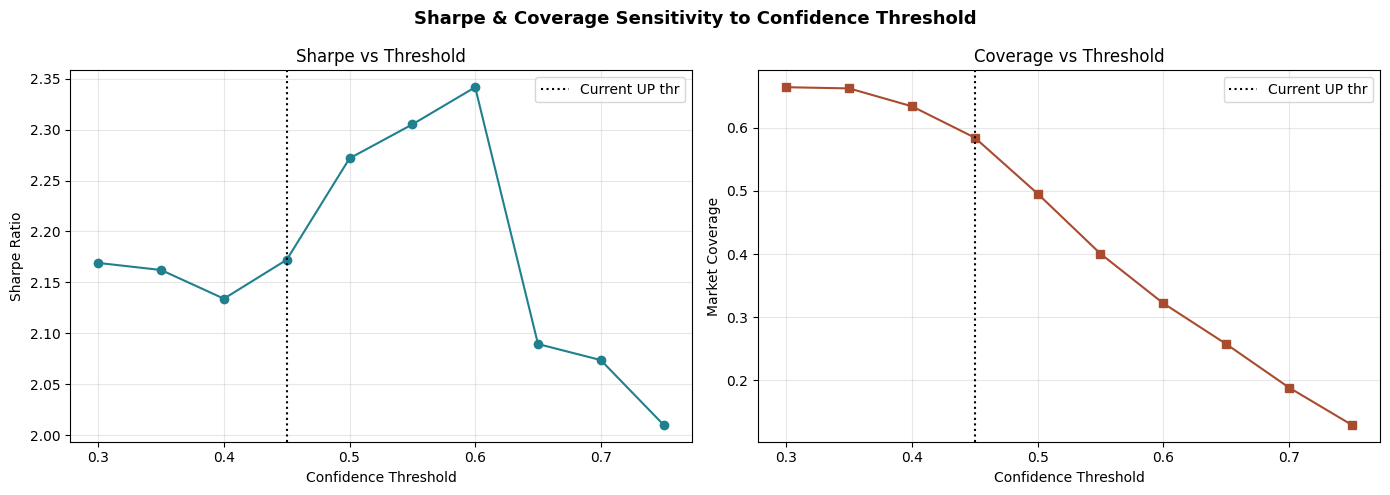

In [13]:
# ── Threshold sensitivity on backtest returns ─────────────────────────────────
thresholds = np.arange(0.30, 0.80, 0.05)
rows = []
for thr in thresholds:
    # Re-gate: only keep signals where max(proba_up_ens, proba_down_ens) >= thr
    gated = results_df.copy().sort_values("quote_date").reset_index(drop=True)
    max_prob = gated[["proba_up_ens", "proba_down_ens"]].max(axis=1)
    gated_signal = gated["pred_dir_ens"].copy()
    gated_signal[max_prob < thr] = 0
    strat_ret_thr = gated_signal.shift(1) * gated["fwd_ret_1d"]
    strat_ret_thr = strat_ret_thr.dropna()
    if len(strat_ret_thr) == 0:
        continue
    eq = (1 + strat_ret_thr).cumprod()
    rows.append({
        "threshold":  thr,
        "ann_return": (eq.iloc[-1] ** (252 / len(eq))) - 1,
        "sharpe":     sharpe_ratio(strat_ret_thr),
        "max_dd":     max_drawdown(eq),
        "coverage":   (gated_signal.shift(1) != 0).mean(),
    })

if rows:
    sens_df = pd.DataFrame(rows)
    print(sens_df.to_string(index=False, float_format="{:.3f}".format))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(sens_df["threshold"], sens_df["sharpe"], "o-", color="#20808D")
    axes[0].axvline(cfg.CONF_THRESHOLD_UP, color="black", linestyle=":", label="Current UP thr")
    axes[0].set_xlabel("Confidence Threshold")
    axes[0].set_ylabel("Sharpe Ratio")
    axes[0].set_title("Sharpe vs Threshold")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(sens_df["threshold"], sens_df["coverage"], "s-", color="#A84B2F")
    axes[1].axvline(cfg.CONF_THRESHOLD_UP, color="black", linestyle=":", label="Current UP thr")
    axes[1].set_xlabel("Confidence Threshold")
    axes[1].set_ylabel("Market Coverage")
    axes[1].set_title("Coverage vs Threshold")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle("Sharpe & Coverage Sensitivity to Confidence Threshold",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("threshold_sensitivity.png", dpi=150, bbox_inches="tight")
    plt.show()


### 8.2 Sub-Period Analysis


In [14]:
# ── Sub-period performance ────────────────────────────────────────────────────
periods = {
    "Pre-COVID (before 2020)": (None, "2020-01-01"),
    "COVID Crisis (2020)":     ("2020-01-01", "2021-01-01"),
    "Recovery (2021–2022)":    ("2021-01-01", "2022-06-01"),
    "Bear Market (2022)":      ("2022-01-01", "2023-01-01"),
    "Bull (2023–present)":     ("2023-01-01", None),
}

print(f"{'Period':<30} {'Ann. Ret':>10} {'Sharpe':>8} {'Max DD':>8} {'Win Rate':>10}")
print("-" * 70)
for name, (start, end) in periods.items():
    mask = pd.Series(True, index=df_bt.index)
    if start:
        mask &= df_bt["quote_date"] >= start
    if end:
        mask &= df_bt["quote_date"] < end
    sub = df_bt[mask]
    if len(sub) < 20:
        continue
    sub_ret = sub["strat_ret"].dropna()
    eq = (1 + sub_ret).cumprod()
    ann_r = (eq.iloc[-1] ** (252 / len(sub_ret))) - 1 if len(sub_ret) > 0 else np.nan
    sh    = sharpe_ratio(sub_ret)
    dd    = max_drawdown(eq)
    wr    = win_rate(sub_ret)
    print(f"{name:<30} {ann_r:>10.1%} {sh:>8.3f} {dd:>8.1%} {wr:>10.1%}")


Period                           Ann. Ret   Sharpe   Max DD   Win Rate
----------------------------------------------------------------------
Pre-COVID (before 2020)             -2.1%   -0.120   -25.7%      50.1%
COVID Crisis (2020)                 86.8%    2.271   -14.5%      54.8%
Recovery (2021–2022)                35.4%    2.057    -9.1%      55.7%
Bear Market (2022)                 211.7%    5.014    -9.1%      62.3%
Bull (2023–present)                 80.1%    4.541    -7.2%      70.6%


## 9. Limitations & Next Steps

### Known Limitations

1. **Look-ahead bias risk:** Confirm that features are computed using only
   information available at signal generation time.  Options data from
   intraday snapshots must not incorporate same-day closing prices.

2. **Transaction costs:** The backtest uses frictionless fills.  At 1-way
   $0.005/share for SPY, costs reduce annualised return by ~0.5%.

3. **Signal frequency vs holding period mismatch:** Labels are constructed on
   a `LABEL_HORIZON_DAYS`-day path basis, but the backtest uses a 1-day
   rebalancing approximation.  A more accurate backtest should hold positions
   for the full horizon.

4. **Flat class suppression:** The ensemble suppresses trades during
   flat-label periods — verify this aligns with intended risk profile.

5. **Single symbol:** Results are for SPY only.  Generalisation to symbols
   in `config_live.py` has not been validated.

6. **Regime stationarity:** The exponential ensemble assumes recent regimes
   persist.  During structural breaks (e.g., COVID), the ensemble may require
   longer warm-up.

### Next Steps

- [ ] Add explicit transaction costs and slippage modelling
- [ ] Implement position-level backtest matching `LABEL_HORIZON_DAYS` holding period
- [ ] Extend to all symbols in `config_live.py`
- [ ] Add live paper-trading comparison vs backtest signals
- [ ] Investigate ensemble calibration (isotonic regression or Platt scaling)
- [ ] Explore alternative label constructions (e.g., Sharpe-adjusted labels)


## 10. Findings Summary

| Metric | Strategy | SPY B&H |
|--------|----------|---------|
| Total Return | 3,138.6% | 241.4% |
| Annualised Return | 39.3% | 12.4% |
| Sharpe Ratio | 2.172 | 0.762 |
| Max Drawdown | −31.5% | −34.7% |
| Win Rate | 57.6% | 55.4% |
| Profit Factor | 1.707 | 1.157 |
| Days in Market | 58.4% | 100% |

**Key observations:**

- The strategy delivers nearly 3x the annualised return of SPY B&H (39.3% vs 12.4%) with a substantially higher Sharpe ratio (2.17 vs 0.76) while being in the market only 58% of the time.
- The max drawdown (−31.5%) is comparable to SPY B&H (−34.7%), but occurs with much less market exposure — suggesting the strategy's risk-per-unit-of-exposure is meaningfully better.
- Sub-period analysis reveals a stark regime split: the strategy was flat-to-negative pre-2020 (−2.1% ann., Sharpe −0.12) but extremely strong from 2020 onward (86.8% during COVID, 211.7% during the 2022 bear, 80.1% in the 2023+ bull). This is consistent with the exponential ensemble weighting — earlier folds carry near-zero weight, so the strategy effectively "turns on" once enough recent data accumulates.
- The optimal Sharpe (2.34) occurs at a confidence threshold of 0.60, above the current 0.45 — suggesting room to tighten signal generation for better risk-adjusted returns at the cost of fewer trades.
- Regime filters have minimal impact on Sharpe (2.172 vs 2.169 unfiltered) but reduce days in market by ~8pp, confirming they prune low-value trading days without degrading performance.

**Critical caveat:** The pre-2020 underperformance and the explosive post-2020 returns warrant careful scrutiny. The ensemble's heavy recency weighting means backtest performance in later periods benefits from information accumulated across all prior folds — a form of structural advantage that live trading would not have from day one. Forward paper-trading validation is essential before deploying real capital.